In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install koreanize-matplotlib

import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 44.3 MB/s eta 0:00:00


# 머신러닝 통합 파이프라인

In [ ]:
df = sns.load_dataset('titanic')

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
X = df.select_dtypes('number').drop('survived',axis=1)
X.head(3)

,pclass,age,sibsp,parch,fare
0,3,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,3,26.0,0,0,7.9250


In [ ]:
y = df['survived']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [ ]:
X_train.shape, X_test.shape

((712, 5), (179, 5))

## (1) Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([
    ('scaler', StandardScaler()),        # Step 1: 전처리
    ('model', RandomForestClassifier(random_state=42))  # Step 2: 모델
])

In [ ]:
pipe

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
pipe.score(X_test,y_test)

0.6201117318435754

In [ ]:
y_pred = pipe.predict(X_test)

In [ ]:
from sklearn.metrics import f1_score, classification_report

f1_score(y_test, y_pred)

0.5211267605633803

## (2) GridSearchCV 와의 조합

In [ ]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

# "스텝이름__파라미터" 규칙
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [ ]:
grid

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

## (3) ColumnTransformer 와의 조합

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ['age', 'sibsp', 'parch', 'fare']
cat_cols = ['pclass', 'sex', 'embarked']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),           # 숫자 → 스케일링
        ('cat', OneHotEncoder(drop='first'), cat_cols)  # 범주 → 원핫인코딩
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('survived',axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [ ]:
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 숫자형: 결측치 → 스케일링
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 범주형: 결측치 → 원핫인코딩
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# 통합 전처리
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# 최종 파이프라인: 전처리 → 모델
full_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

full_pipe.fit(X_train, y_train)  # 결측치 처리 + 스케일링 + 인코딩 + 학습, 한 번에!

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sibsp', 'parch',
                                                   'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['pclass', 'sex',
                                                   'embarked'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred = full_pipe.predict(X_test)
f1_score(y_test, y_pred)

0.7441860465116279

In [ ]:
X_test.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
565,3,male,24.0,2,0,24.1500,S,Third,man,True,NaN,Southampton,no,False
160,3,male,44.0,0,1,16.1000,S,Third,man,True,NaN,Southampton,no,False
553,3,male,22.0,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,yes,True
860,3,male,41.0,2,0,14.1083,S,Third,man,True,NaN,Southampton,no,False
241,3,female,NaN,1,0,15.5000,Q,Third,woman,False,NaN,Queenstown,yes,False


# 실전! 머신러닝 통합 파이프라인

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

# KDD Cup 99 데이터셋 (10% 샘플)
kdd = fetch_kddcup99(subset='SA', percent10=True, as_frame=True, random_state=42)

X = kdd.data
y = kdd.target

X = X.apply(pd.to_numeric, errors='ignore')
object_cols = X.select_dtypes(include=['object']).columns

for col in object_cols:
    X[col] = X[col].str.decode('utf-8')

y = y.str.decode('utf-8')

print(f"데이터 크기: {X.shape}")
print(f"타겟 고유값: {y.nunique()}개")
print(y.value_counts().head(10))

데이터 크기: (100655, 41)
타겟 고유값: 12개
labels
normal.         97278
smurf.           2409
neptune.          898
back.              15
satan.             15
ipsweep.           10
teardrop.           9
portsweep.          8
warezclient.        8
pod.                3
Name: count, dtype: int64


## (1) 타겟 변환 + 분할

In [ ]:
y = (y != 'normal.').astype(int)
y.value_counts()

,count
labels,
0,97278
1,3377


In [ ]:
y.mean()

np.float64(0.03355024588942427)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                random_state=42,
                                                stratify=y)

In [ ]:
X_train.shape, X_test.shape

((75491, 41), (25164, 41))

In [ ]:
y_train.mean(), y_test.mean()

(np.float64(0.03355366864924295), np.float64(0.03353997774598633))

> **만약 불균형 데이터를 처리하고 싶다면?**  
SMOTE 알고리즘을 통해 X_train_sm, y_train_sm 형태로 오버샘플링할 수 있다.

## (2) ColumnTransformer 구축

In [ ]:
num_cols = X.select_dtypes('number').columns.to_list()

In [ ]:
cat_cols = X.select_dtypes('object').columns.to_list()

In [ ]:
len(num_cols), len(cat_cols)

(38, 3)

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_cols), # 이름, 변환기, 변환할 컬럼명 리스트
        ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['duration', 'src_bytes', 'dst_bytes', 'land',
                                  'wrong_fragment', 'urgent', 'hot',
                                  'num_failed_logins', 'logged_in',
                                  'num_compromised', 'root_shell',
                                  'su_attempted', 'num_root',
                                  'num_file_creations', 'num_shells',
                                  'num_access_files', 'num_outbound_cmds',
                                  'is_host_login', 'is_guest_login', 'count',
                                  'srv_count', 'serror_rate', 'srv_serror_rate',
                                  'rerror_rate', 'srv_rerror_rate',
                                  'same_srv_rate', 'diff_srv_rate',
                                  'srv_diff_host_rate', 'dst_host_count',
                                  'dst_host_srv_count', ...]),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['protocol_type', 'service', 'flag'])])

 ## (3) Pipeline으로 모델 학습


In [ ]:
from sklearn.linear_model import LogisticRegression

pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
    ])

In [ ]:
pipe

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'num_outbound_cmds',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['protocol_type', 'service',
                                                   'flag'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'num_outbound_cmds',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['protocol_type', 'service',
                                                   'flag'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
pipe.score(X_test, y_test)

0.9993244317278652

In [ ]:
y_pred = pipe.predict(X_test)
f1_score(y_test, y_pred)

0.9898628503279666

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24320
           1       1.00      0.98      0.99       844

    accuracy                           1.00     25164
   macro avg       1.00      0.99      0.99     25164
weighted avg       1.00      1.00      1.00     25164



## (4) 도전 과제: 모델 교체와 비교

In [ ]:
pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
    ])

In [ ]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'num_outbound_cmds',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['protocol_type', 'service',
                                                   'flag'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred = pipe.predict(X_test)
f1_score(y_test, y_pred)

0.9970291146761735

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24320
           1       1.00      0.99      1.00       844

    accuracy                           1.00     25164
   macro avg       1.00      1.00      1.00     25164
weighted avg       1.00      1.00      1.00     25164



In [ ]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['duration',
                                                                          'src_bytes',
                                                                          'dst_bytes',
                                                                          'land',
                                                                          'wrong_fragment',
                                                                          'urgent',
                                                                          'hot',
                                                                          'num_failed_logins',
                                                                          'logged_in',
                                                                          'num_compromised',
                                                                          'root_shell',
                                                                          'su_attempted',
                                                                          'num_root',
                                                                          'num_file_creations',
                                                                          'num_shells',
                                                                          'num_access_files',
                                                                          'num_outbound_cmds',
                                                                          'is_h...
                                                                          'rerror_rate',
                                                                          'srv_rerror_rate',
                                                                          'same_srv_rate',
                                                                          'diff_srv_rate',
                                                                          'srv_diff_host_rate',
                                                                          'dst_host_count',
                                                                          'dst_host_srv_count', ...]),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['protocol_type',
                                                                          'service',
                                                                          'flag'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [ ]:
grid.best_estimator_

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'num_outbound_cmds',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['protocol_type', 'service',
                                                   'flag'])])),
                ('model',
                 RandomForestClassifier(max_depth=7, n_estimators=200,
                                        random_state=42))])

In [ ]:
grid.best_score_

np.float64(0.9952341393277747)

# Feature Importance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Titanic 데이터 준비
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ColumnTransformer로 전처리 통합
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Pclass', 'Sex', 'Embarked']

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols), # 결측치 처리
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')), # 결측치 처리
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')) # 인코더
    ]), cat_cols)
])

# 전처리 적용 + 피처명 추출
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print(f"변환된 피처: {list(feature_names)}")

# Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_t, y_train)

변환된 피처: ['num__Age', 'num__SibSp', 'num__Parch', 'num__Fare', 'cat__Pclass_2', 'cat__Pclass_3', 'cat__Sex_male', 'cat__Embarked_Q', 'cat__Embarked_S']


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
rf.feature_importances_

array([0.24882292, 0.04793304, 0.03736505, 0.28049696, 0.0181857 ,
       0.06565346, 0.26693239, 0.00923722, 0.02537324])

In [ ]:
# 중요도 정렬
feat_imp = pd.Series(rf.feature_importances_, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=True)

In [ ]:
feat_imp

,0
cat__Embarked_Q,0.009237
cat__Pclass_2,0.018186
cat__Embarked_S,0.025373
num__Parch,0.037365
num__SibSp,0.047933
cat__Pclass_3,0.065653
num__Age,0.248823
cat__Sex_male,0.266932
num__Fare,0.280497


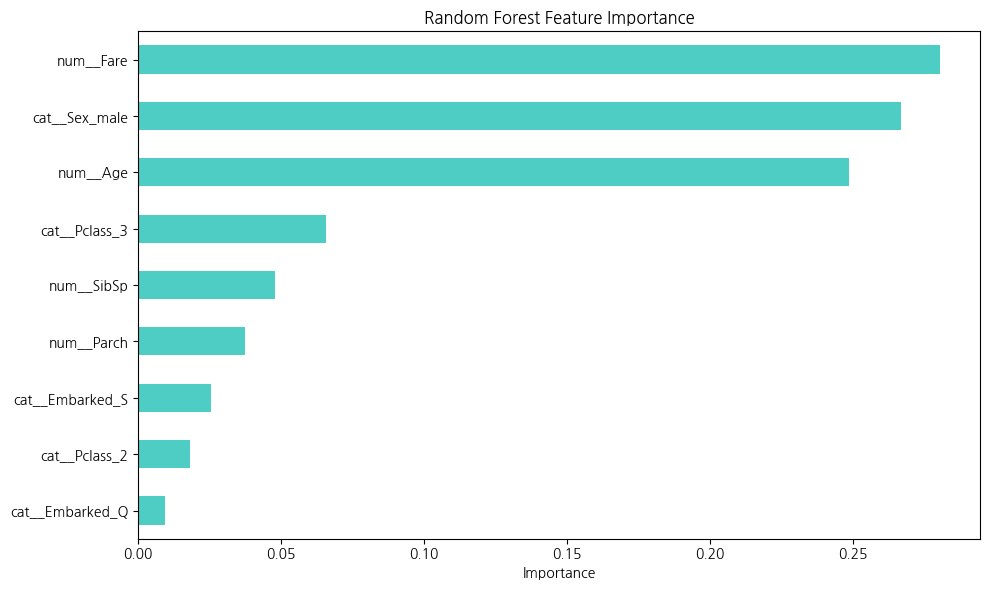

🔑 Top 3 중요 피처:
  num__Fare: 0.2805
  cat__Sex_male: 0.2669
  num__Age: 0.2488


In [ ]:
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='#4ECDC4')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("🔑 Top 3 중요 피처:")
for name, imp in feat_imp.sort_values(ascending=False).head(3).items():
    print(f"  {name}: {imp:.4f}")

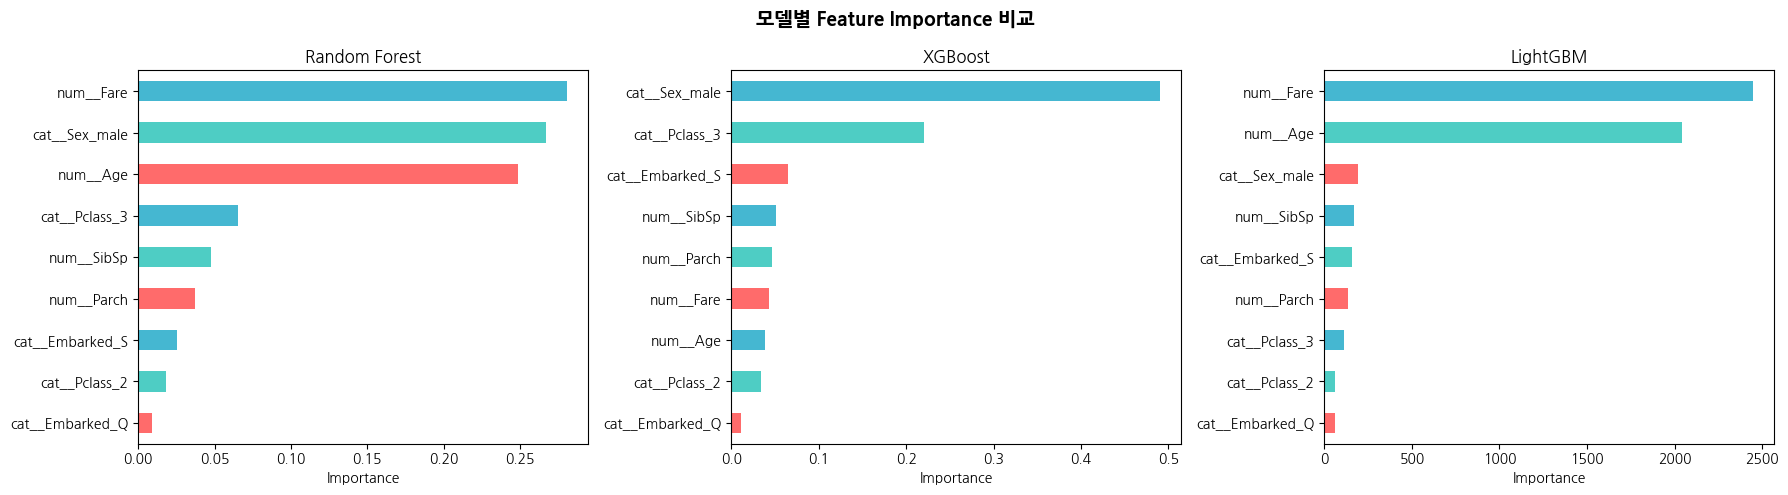

In [ ]:
# 세 모델의 Feature Importance 비교
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42,
                              use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_t, y_train)
    imp = pd.Series(model.feature_importances_, index=feature_names)
    imp = imp.sort_values(ascending=True)
    imp.plot(kind='barh', ax=axes[idx], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Importance')

plt.suptitle('모델별 Feature Importance 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

# Permutation Importance (테스트 데이터 기반!)
perm_result = permutation_importance(
    rf, X_test_t, y_test,
    n_repeats=10,       # 각 피처를 10번 반복 섞음
    random_state=42,
    scoring='accuracy'  # 평가 기준 (분류: accuracy, 회귀: r2 등)
)

# 결과 확인
print("반환값 3가지:")
print(f"  importances_mean: 각 피처의 평균 성능 감소량")
print(f"  importances_std:  반복 간 표준편차 (안정성)")
print(f"  importances:      반복별 상세 값")

반환값 3가지:
  importances_mean: 각 피처의 평균 성능 감소량
  importances_std:  반복 간 표준편차 (안정성)
  importances:      반복별 상세 값


In [ ]:
perm_result.importances_mean

array([ 0.07039106, -0.00111732,  0.01843575,  0.07150838, -0.00167598,
        0.06648045,  0.18324022, -0.00111732,  0.00446927])

In [ ]:
perm_result.importances_std

array([0.01770165, 0.00961154, 0.00792036, 0.01166515, 0.00436327,
       0.01444974, 0.03787363, 0.00418062, 0.00928114])

In [ ]:
X_test_t.shape

(179, 9)

In [ ]:
perm_result.importances

array([[ 0.0726257 ,  0.0726257 ,  0.05586592,  0.06703911,  0.04469274,
         0.06703911,  0.04469274,  0.09497207,  0.08938547,  0.09497207],
       [ 0.00558659,  0.00558659,  0.        ,  0.        , -0.02234637,
         0.        ,  0.00558659,  0.00558659,  0.00558659, -0.01675978],
       [ 0.01675978,  0.01117318,  0.02234637,  0.03351955,  0.00558659,
         0.01675978,  0.02234637,  0.01675978,  0.01117318,  0.02793296],
       [ 0.07821229,  0.08379888,  0.0726257 ,  0.08379888,  0.06145251,
         0.08379888,  0.06703911,  0.06703911,  0.0726257 ,  0.04469274],
       [-0.00558659,  0.00558659,  0.00558659, -0.00558659,  0.        ,
        -0.00558659, -0.00558659, -0.00558659,  0.        ,  0.        ],
       [ 0.08379888,  0.03910615,  0.06703911,  0.0726257 ,  0.08379888,
         0.05027933,  0.06703911,  0.05027933,  0.0726257 ,  0.07821229],
       [ 0.26256983,  0.16201117,  0.19553073,  0.21787709,  0.13407821,
         0.15642458,  0.1452514 ,  0.16201117

In [ ]:
# 트리 기반 vs Permutation 비교
compare = pd.DataFrame({
    '트리 기반 중요도': pd.Series(rf.feature_importances_, index=feature_names),
    'Permutation 중요도': perm_result.importances_mean
}, index=feature_names)

# 순위로 비교하면 차이가 더 명확
compare['트리 순위'] = compare['트리 기반 중요도'].rank(ascending=False).astype(int)
compare['Perm 순위'] = compare['Permutation 중요도'].rank(ascending=False).astype(int)
compare['순위 변화'] = compare['트리 순위'] - compare['Perm 순위']

print("📊 Feature Importance 비교 (순위 변화 주목!):")
print(compare.sort_values('Perm 순위').round(4))

📊 Feature Importance 비교 (순위 변화 주목!):
                 트리 기반 중요도  Permutation 중요도  트리 순위  Perm 순위  순위 변화
cat__Sex_male       0.2669           0.1832      2        1      1
num__Fare           0.2805           0.0715      1        2     -1
num__Age            0.2488           0.0704      3        3      0
cat__Pclass_3       0.0657           0.0665      4        4      0
num__Parch          0.0374           0.0184      6        5      1
cat__Embarked_S     0.0254           0.0045      7        6      1
cat__Embarked_Q     0.0092          -0.0011      9        7      2
num__SibSp          0.0479          -0.0011      5        8     -3
cat__Pclass_2       0.0182          -0.0017      8        9     -1


# SHAP

In [ ]:
# 모델 학습
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_t, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
import shap

# SHAP Explainer 생성
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_t)

print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"모델 정확도: {model.score(X_test_t, y_test):.4f}")

SHAP values shape: (179, 9, 2)
모델 정확도: 0.8212


In [ ]:
X_test_t.shape

(179, 9)

In [ ]:
shap_values

array([[[ 0.00048157, -0.00048157],
        [-0.04400521,  0.04400521],
        [-0.0028597 ,  0.0028597 ],
        ...,
        [ 0.11373946, -0.11373946],
        [ 0.00898848, -0.00898848],
        [ 0.0423267 , -0.0423267 ]],

       [[ 0.06738202, -0.06738202],
        [-0.00920489,  0.00920489],
        [-0.01398849,  0.01398849],
        ...,
        [ 0.12731939, -0.12731939],
        [-0.00187389,  0.00187389],
        [ 0.02730301, -0.02730301]],

       [[-0.00168987,  0.00168987],
        [-0.00399106,  0.00399106],
        [ 0.00978582, -0.00978582],
        ...,
        [ 0.20113025, -0.20113025],
        [-0.00787978,  0.00787978],
        [-0.06795876,  0.06795876]],

       ...,

       [[ 0.05054525, -0.05054525],
        [-0.00051025,  0.00051025],
        [ 0.01112285, -0.01112285],
        ...,
        [ 0.22863794, -0.22863794],
        [ 0.00072554, -0.00072554],
        [ 0.03006387, -0.03006387]],

       [[-0.00272129,  0.00272129],
        [-0.01557055,  0.01

In [ ]:
shap_values[0, :, 1]

array([-0.00048157,  0.04400521,  0.0028597 , -0.04502327,  0.00583674,
       -0.0703725 , -0.11373946, -0.00898848, -0.0423267 ])

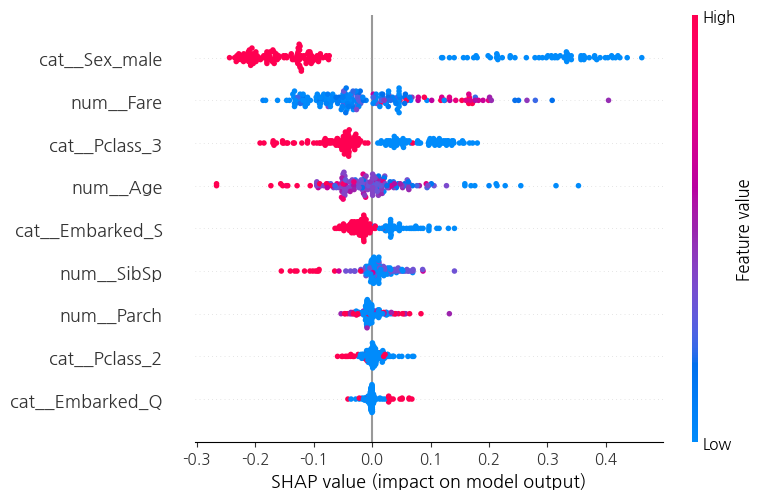

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test_t, feature_names=feature_names)

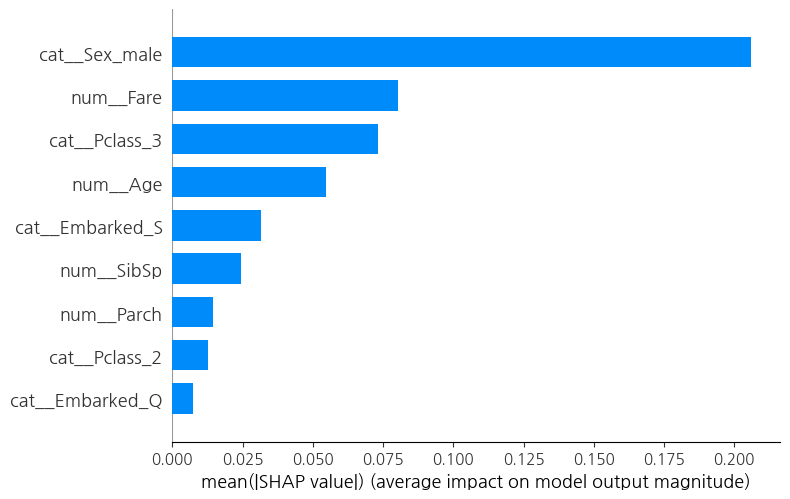

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test_t, feature_names=feature_names,
                  plot_type='bar')

실제값: 생존
예측값: 생존
생존 확률: 0.995


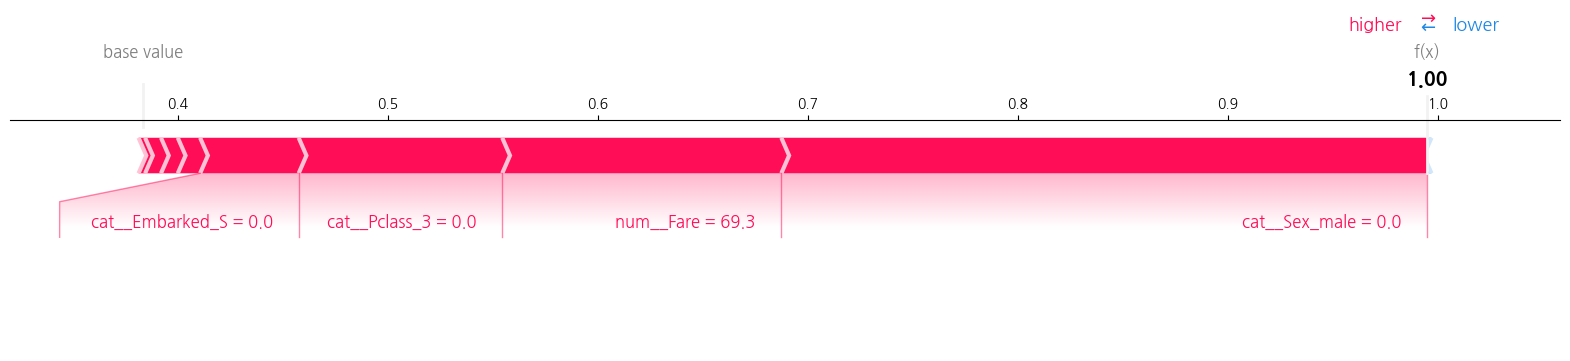

In [ ]:
# 특정 승객 1명의 예측 해석
idx = 25  # 첫 번째 테스트 샘플

print(f"실제값: {'생존' if y_test.iloc[idx] == 1 else '사망'}")
print(f"예측값: {'생존' if model.predict(X_test_t[[idx]])[0] == 1 else '사망'}")
print(f"생존 확률: {model.predict_proba(X_test_t[[idx]])[0][1]:.3f}")

# Force Plot (개별 설명)
shap.force_plot(explainer.expected_value[1],
                shap_values[idx, :, 1],
                pd.Series(X_test_t[idx], index=feature_names),
                matplotlib=True)
plt.show()

# K-Means

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Iris 데이터 로딩
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# 꽃잎 피처 2개만 사용 (시각화를 위해)
X = df[['petal length (cm)', 'petal width (cm)']]

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"데이터 크기: {X_scaled.shape}")
print(f"실제 품종 수: {len(set(iris.target))}")  # 참고용 (학습에는 안 씀)

데이터 크기: (150, 2)
실제 품종 수: 3


In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
# K=3으로 군집화
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [ ]:
df['Cluster'] = kmeans.labels_

In [ ]:
print("군집별 데이터 수:")
print(df['Cluster'].value_counts().sort_index())

군집별 데이터 수:
Cluster
0    50
1    42
2    27
3    31
Name: count, dtype: int64


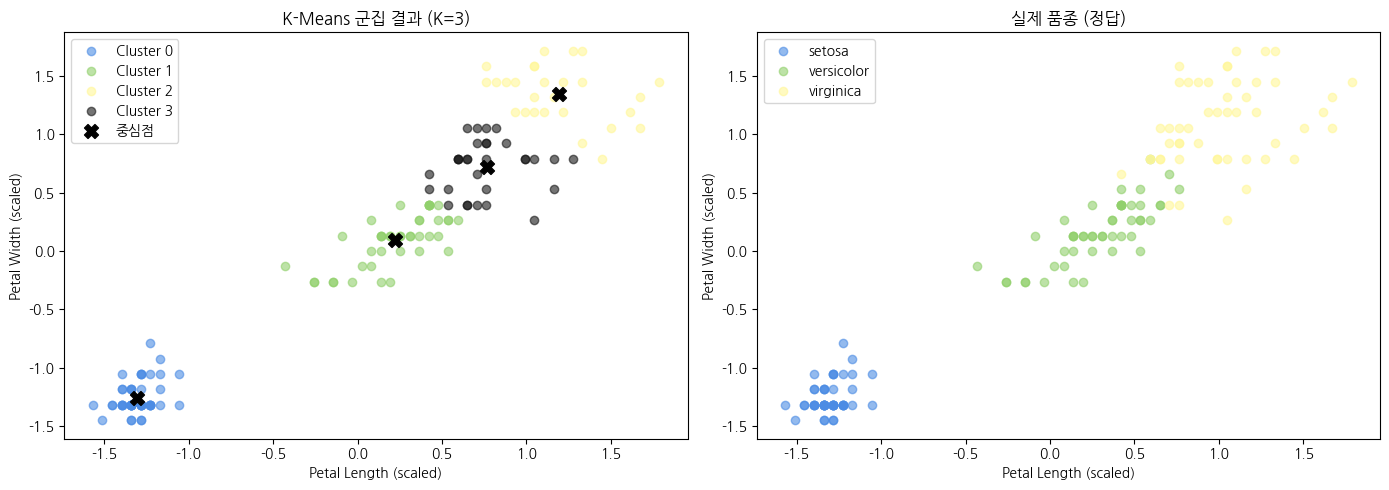

In [ ]:
# 군집 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: K-Means 군집 결과
colors = ['#4C8CE4', '#91D06C', '#FFF799','#181818']
for i in range(4):
    mask = kmeans.labels_ == i
    axes[0].scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                    c=colors[i], label=f'Cluster {i}', alpha=0.6)

# 중심점 표시
centers = kmeans.cluster_centers_
axes[0].scatter(centers[:, 0], centers[:, 1],
                c='black', marker='X', s=100, label='중심점')
axes[0].set_title('K-Means 군집 결과 (K=3)')
axes[0].set_xlabel('Petal Length (scaled)')
axes[0].set_ylabel('Petal Width (scaled)')
axes[0].legend()

# 오른쪽: 실제 품종 (비교용)
for i in range(3):
    mask = iris.target == i
    axes[1].scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                    c=colors[i], label=iris.target_names[i], alpha=0.6)
axes[1].set_title('실제 품종 (정답)')
axes[1].set_xlabel('Petal Length (scaled)')
axes[1].set_ylabel('Petal Width (scaled)')
axes[1].legend()

plt.tight_layout()
plt.show()

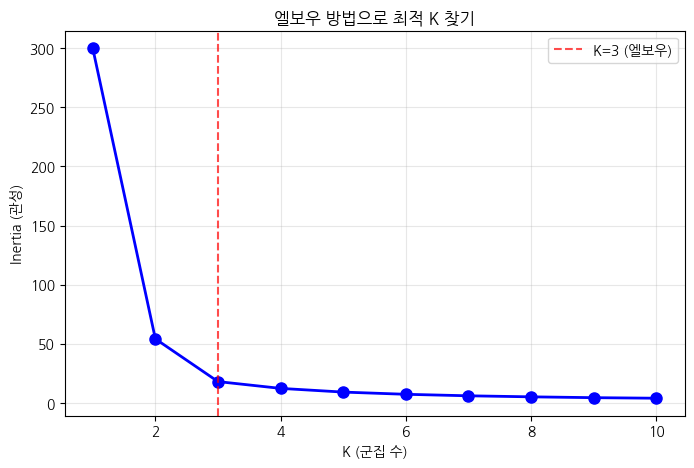

In [ ]:
# 엘보우 방법
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# 시각화
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 (엘보우)')
plt.xlabel('K (군집 수)')
plt.ylabel('Inertia (관성)')
plt.title('엘보우 방법으로 최적 K 찾기')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

print("=== K별 실루엣 점수 ===")
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k} : {score:.3f}")

=== K별 실루엣 점수 ===
K = 2 : 0.743
K = 3 : 0.674
K = 4 : 0.599
K = 5 : 0.574
K = 6 : 0.582
K = 7 : 0.573


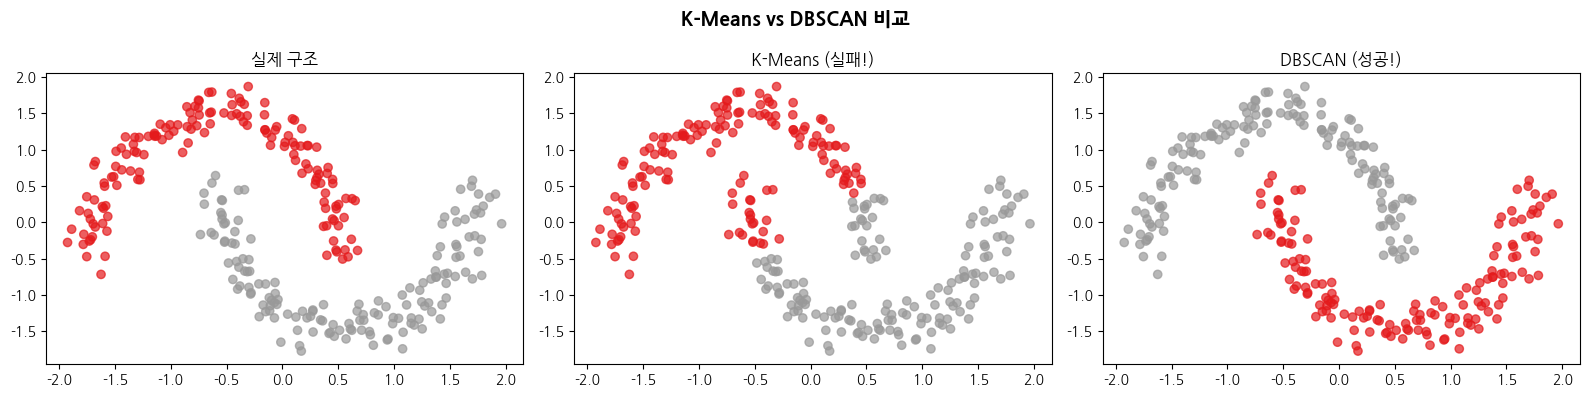

DBSCAN 결과: 2개 군집, 0개 이상치


In [ ]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 반달 모양 데이터 (K-Means가 실패하는 케이스)
X, y_true = make_moons(n_samples=300, noise=0.08, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

# K-Means vs DBSCAN 비교
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 원본
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, cmap='Set1', alpha=0.7)
axes[0].set_title('실제 구조')

# K-Means
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=km_labels, cmap='Set1', alpha=0.7)
axes[1].set_title('K-Means (실패!)')

# DBSCAN
db = DBSCAN(eps=0.3, min_samples=5)
db_labels = db.fit_predict(X_scaled)

axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=db_labels, cmap='Set1', alpha=0.7)
axes[2].set_title('DBSCAN (성공!)')

plt.suptitle('K-Means vs DBSCAN 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 이상치 확인
n_noise = (db_labels == -1).sum()
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"DBSCAN 결과: {n_clusters}개 군집, {n_noise}개 이상치")

In [ ]:
# 1. 필요한 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# 2. 예시 데이터 생성 (동물의 특징)
# 데이터: [몸무게(kg), 최고 속도(km/h)]
X = np.array([
    [5, 20],   # 치와와 (Chihuahua)
    [8, 25],   # 비글 (Beagle)
    [40, 50],  # 늑대 (Wolf)
    [35, 45],  # 시베리안 허스키 (Husky)
    [80, 70],  # 치타 (Cheetah)
    [4, 30]    # 고양이 (Cat)
])
labels = ['Chihuahua', 'Beagle', 'Wolf', 'Husky', 'Cheetah', 'Cat']

In [ ]:
X

array([[ 5, 20],
       [ 8, 25],
       [40, 50],
       [35, 45],
       [80, 70],
       [ 4, 30]])

In [ ]:
# 3. 계층적 군집 수행 (linkage)
# 'ward' 방식은 군집 내 분산을 최소화하는 방향으로 군집을 합칩니다.
Z = linkage(X, method='ward')

In [ ]:
Z

array([[ 0.        ,  1.        ,  5.83095189,  2.        ],
       [ 2.        ,  3.        ,  7.07106781,  2.        ],
       [ 5.        ,  6.        ,  9.12870929,  3.        ],
       [ 4.        ,  7.        , 55.52777083,  3.        ],
       [ 8.        ,  9.        , 95.1209756 ,  6.        ]])

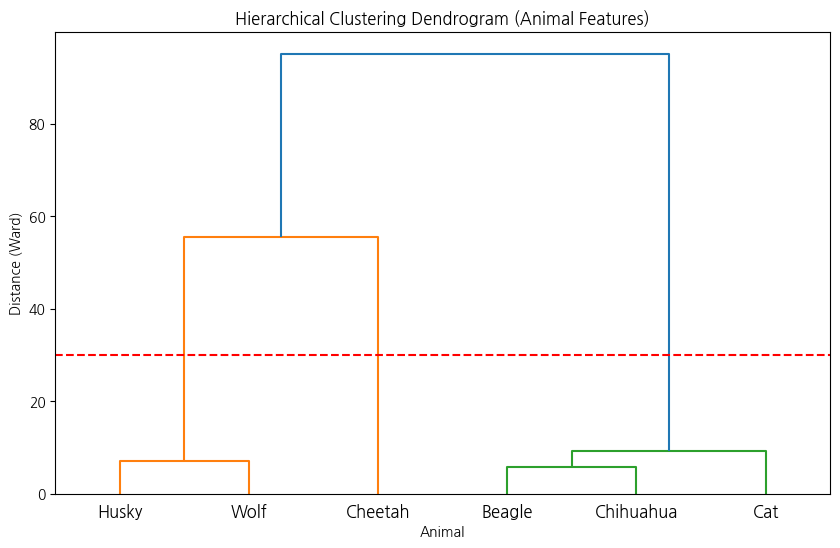

In [ ]:
# 4. 덴드로그램 시각화 (개선된 버전)
plt.figure(figsize=(10, 6))
dendrogram(
    Z,
    orientation='top',
    labels=labels, # 각 데이터 포인트에 이름(라벨) 부여
    distance_sort='descending'
)
plt.title("Hierarchical Clustering Dendrogram (Animal Features)")
plt.xlabel("Animal")
plt.ylabel("Distance (Ward)")

# 가로선을 그어 군집의 개수를 결정하는 예시
plt.axhline(y=30, color='r', linestyle='--')
plt.show()

In [ ]:
# 5. 군집 라벨 추출

# 방법 1: 군집의 개수(K)를 2개로 지정
labels_by_k = fcluster(Z, t=3, criterion='maxclust')
print(f"군집 개수(K=3) 기준 라벨: {labels_by_k}")

군집 개수(K=3) 기준 라벨: [1 1 2 2 3 1]


In [ ]:
# 방법 2: 거리(distance)를 30으로 지정
# 덴드로그램에서 y=30 가로선 아래로 형성되는 군집을 의미
labels_by_dist = fcluster(Z, t=30, criterion='distance')
print(f"거리(t=30) 기준 라벨:     {labels_by_dist}")

거리(t=30) 기준 라벨:     [1 1 2 2 3 1]


# PCA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

# 데이터 준비
cancer = load_breast_cancer()
X = cancer.data   # 30차원!
y = cancer.target  # 0=악성, 1=양성

print(f"피처 수: {X.shape[1]}개")
print(f"샘플 수: {X.shape[0]}개")
print(f"피처 예시: {cancer.feature_names[:5]}...")

피처 수: 30개
샘플 수: 569개
피처 예시: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']...


In [ ]:
X[:,:5]

array([[1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, 1.326e+03, 8.474e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, 1.203e+03, 1.096e-01],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, 8.581e+02, 8.455e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, 1.265e+03, 1.178e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, 1.810e+02, 5.263e-02]])

In [ ]:
# 스케일링 (PCA 전 필수!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled[:,:5]

array([[ 1.09706398, -2.07333501,  1.26993369,  0.9843749 ,  1.56846633],
       [ 1.82982061, -0.35363241,  1.68595471,  1.90870825, -0.82696245],
       [ 1.57988811,  0.45618695,  1.56650313,  1.55888363,  0.94221044],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578,  0.57795264, -0.84048388],
       [ 1.83834103,  2.33645719,  1.98252415,  1.73521799,  1.52576706],
       [-1.80840125,  1.22179204, -1.81438851, -1.34778924, -3.11208479]])

In [ ]:
# PCA: 30차원 → 2차원
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print(f"\n원본 차원: {X_scaled.shape}")
print(f"PCA 후 차원: {X_pca.shape}")

print(f"\n각 주성분의 설명 분산 비율:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.4f} ({ratio*100:.1f}%)")

print(f"\n누적 설명 분산: {pca.explained_variance_ratio_.sum()*100:.1f}%")



원본 차원: (569, 30)
PCA 후 차원: (569, 2)

각 주성분의 설명 분산 비율:
  PC1: 0.4427 (44.3%)
  PC2: 0.1897 (19.0%)

누적 설명 분산: 63.2%


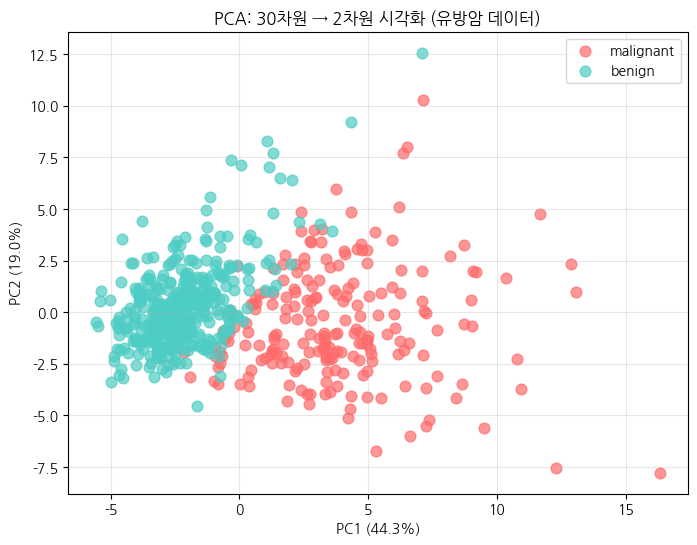

In [ ]:
# 2D 시각화 — 30차원을 2차원으로 압축했는데도 구분이 됩니다!
plt.figure(figsize=(8, 6))
colors = ['#FF6B6B', '#4ECDC4']

for i, name in enumerate(cancer.target_names):
    mask = y == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=name, alpha=0.7, s=60)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA: 30차원 → 2차원 시각화 (유방암 데이터)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

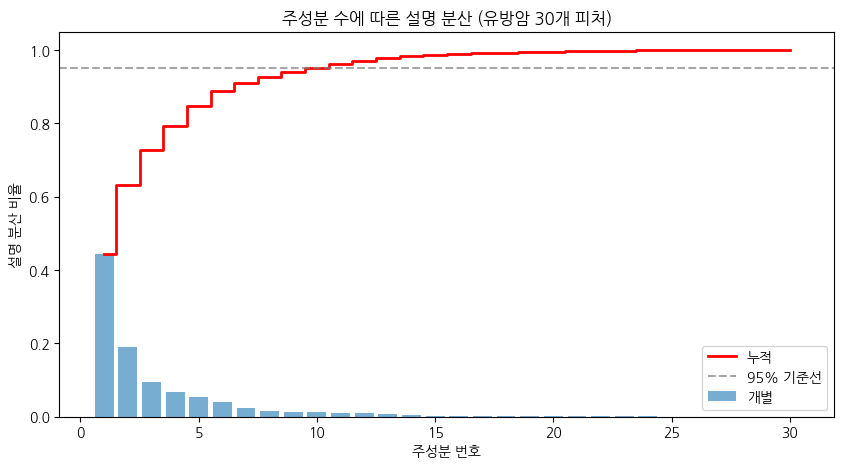

95% 설명에 필요한 주성분 수: 10개 (30개 → 10개로 압축!)


In [ ]:
# 전체 주성분의 설명 분산 비율 (30개 주성분 모두 확인)
pca_full = PCA()
pca_full.fit(X_scaled)

# 누적 설명 분산 그래프
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(cumsum)+1), pca_full.explained_variance_ratio_,
        alpha=0.6, label='개별')
plt.step(range(1, len(cumsum)+1), cumsum, where='mid',
         color='red', linewidth=2, label='누적')
plt.axhline(y=0.95, color='gray', linestyle='--', alpha=0.7, label='95% 기준선')
plt.xlabel('주성분 번호')
plt.ylabel('설명 분산 비율')
plt.title('주성분 수에 따른 설명 분산 (유방암 30개 피처)')
plt.legend()
plt.show()

n_95 = np.argmax(cumsum >= 0.95) + 1
print(f"95% 설명에 필요한 주성분 수: {n_95}개 (30개 → {n_95}개로 압축!)")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# PCA 없이 (30개 피처 전부)
scores_raw = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_scaled, y, cv=5, scoring='accuracy'
)

# PCA로 차원 축소 후 (95% 설명 유지)
X_pca_95 = PCA(n_components=0.95).fit_transform(X_scaled)
scores_pca = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_pca_95, y, cv=5, scoring='accuracy'
)

print(f"PCA 없이: {scores_raw.mean():.4f} (피처 {X_scaled.shape[1]}개)")
print(f"PCA 후:   {scores_pca.mean():.4f} (피처 {X_pca_95.shape[1]}개)")
print(f"→ 피처를 {X_scaled.shape[1]}개에서 {X_pca_95.shape[1]}개로 줄이고도 성능 유지!")

PCA 없이: 0.9561 (피처 30개)
PCA 후:   0.9508 (피처 10개)
→ 피처를 30개에서 10개로 줄이고도 성능 유지!
